# NQ Intraday Research Notebook

In [191]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## 1) Setup projet

In [192]:
from pathlib import Path
import sys
root = Path.cwd().resolve().parent
sys.path.insert(0, str(root))
print("Project root set to:", root)


Project root set to: C:\Donnees\Business\Trading\Code\algo-trading-intraday-research


In [193]:
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

from src.config.paths import RAW_DATA_DIR, ensure_directories
from src.data.loader import load_ohlcv_csv
from src.data.validation import validate_ohlcv
from src.data.cleaning import clean_ohlcv
from src.data.session import extract_rth, add_session_date
from src.features.intraday import add_intraday_features
from src.features.opening_range import compute_opening_range
from src.features.returns import add_simple_returns, add_log_returns
from src.features.volatility import add_rolling_std, add_atr
from src.strategy.orb import ORBStrategy
from src.engine.execution_model import ExecutionModel
from src.engine.backtester import run_backtest
from src.engine.portfolio import build_equity_curve
from src.analytics.metrics import compute_metrics
from src.analytics.diagnostics import performance_by_weekday, performance_by_month, performance_by_year
from src.analytics.heatmaps import run_orb_grid_search, pivot_heatmap
from src.visualization.plots import plot_trade_histogram, plot_pnl_distribution, plot_cumulative_pnl
from src.visualization.equity import plot_equity_curve, plot_drawdown_curve

ensure_directories()
pd.set_option('display.width', 200)
pd.set_option('display.max_columns', 50)

## 2) Chargement d’un sample 1-minute

In [194]:
# api_key = 'xxx'

# import databento as db

# # Connexion au service historical
# client = db.Historical(api_key)

# # Récupération du MNQ front month en bougies 1 minute
# data = client.timeseries.get_range(
#     dataset="GLBX.MDP3",      # CME Globex MDP 3.0
#     symbols="MNQ.v.0",        # MNQ continuous front month
#     stype_in="continuous",
#     schema="ohlcv-1m",
#     start="2015-01-01T00:00:00Z",
#     end="2026-03-03T0:00:00Z",
# )

# # Conversion en DataFrame pandas
# df = data.to_df()

In [195]:
df_raw = pd.read_parquet(RAW_DATA_DIR / 'MNQ_1mim.parquet')

In [196]:
df_raw.rename(columns={'ts_event': 'timestamp'}, inplace=True)
df_raw['timestamp'] = pd.to_datetime(df_raw['timestamp'], errors="coerce")
df_raw['timestamp'] = df_raw['timestamp'].dt.tz_convert("America/New_York")

In [197]:
# df.to_parquet(RAW_DATA_DIR / 'MNQ_1mim.parquet')

In [198]:
# df_raw = load_ohlcv_csv(RAW_DATA_DIR / 'MNQ_1mim.csv')
df_raw.head()

,timestamp,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol
0,2019-05-05 18:03:00-04:00,33,1,8078,7748.75,7748.75,7748.75,7748.75,1,MNQ.v.0
1,2019-05-05 18:12:00-04:00,33,1,8078,7713.75,7713.75,7713.75,7713.75,1,MNQ.v.0
2,2019-05-05 18:17:00-04:00,33,1,8078,7713.75,7713.75,7713.75,7713.75,2,MNQ.v.0
3,2019-05-05 18:23:00-04:00,33,1,8078,7713.50,7713.50,7713.50,7713.50,1,MNQ.v.0
4,2019-05-05 18:25:00-04:00,33,1,8078,7718.25,7718.25,7718.25,7718.25,1,MNQ.v.0


## 3) Contrôle qualité de la donnée

In [199]:
quality_report = validate_ohlcv(df_raw)
quality_report

QualityReport(rows=2402784, missing_required_columns=[], is_chronological=True, duplicate_timestamps=0, invalid_ohlc_rows=0, negative_volume_rows=0)

## 4) Nettoyage

In [200]:
df = clean_ohlcv(df_raw)
len(df), df.head()

(2402784,
                   timestamp  rtype  publisher_id  instrument_id     open     high      low    close  volume   symbol
 0 2019-05-05 18:03:00-04:00     33             1           8078  7748.75  7748.75  7748.75  7748.75       1  MNQ.v.0
 1 2019-05-05 18:12:00-04:00     33             1           8078  7713.75  7713.75  7713.75  7713.75       1  MNQ.v.0
 2 2019-05-05 18:17:00-04:00     33             1           8078  7713.75  7713.75  7713.75  7713.75       2  MNQ.v.0
 3 2019-05-05 18:23:00-04:00     33             1           8078  7713.50  7713.50  7713.50  7713.50       1  MNQ.v.0
 4 2019-05-05 18:25:00-04:00     33             1           8078  7718.25  7718.25  7718.25  7718.25       1  MNQ.v.0)

## 5) Filtrage de session (RTH)

In [201]:
df_rth = extract_rth(df)
df_rth = add_session_date(df_rth)
df_rth[['timestamp', 'session_date']].head()

,timestamp,session_date
0,2019-05-06 09:30:00-04:00,2019-05-06
1,2019-05-06 09:31:00-04:00,2019-05-06
2,2019-05-06 09:32:00-04:00,2019-05-06
3,2019-05-06 09:33:00-04:00,2019-05-06
4,2019-05-06 09:34:00-04:00,2019-05-06


## 6) Construction de features intraday

In [202]:
df_feat = add_intraday_features(df_rth)
df_feat = add_simple_returns(df_feat)
df_feat = add_log_returns(df_feat)
df_feat = add_rolling_std(df_feat, window=5)
df_feat = add_atr(df_feat, window=5)
df_feat.head()

,timestamp,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,session_date,minute_of_day,weekday,bar_in_session,ret_simple,ret_log,vol_std_5,atr_5
0,2019-05-06 09:30:00-04:00,33,1,8078,7690.00,7695.00,7676.50,7693.25,452,MNQ.v.0,2019-05-06,570,0,1,NaN,NaN,NaN,NaN
1,2019-05-06 09:31:00-04:00,33,1,8078,7693.75,7707.25,7693.50,7706.75,448,MNQ.v.0,2019-05-06,571,0,2,0.001755,0.001753,NaN,NaN
2,2019-05-06 09:32:00-04:00,33,1,8078,7706.25,7714.50,7706.25,7710.50,349,MNQ.v.0,2019-05-06,572,0,3,0.000487,0.000486,NaN,NaN
3,2019-05-06 09:33:00-04:00,33,1,8078,7711.75,7721.50,7711.25,7721.50,492,MNQ.v.0,2019-05-06,573,0,4,0.001427,0.001426,NaN,NaN
4,2019-05-06 09:34:00-04:00,33,1,8078,7721.75,7725.00,7715.75,7725.00,280,MNQ.v.0,2019-05-06,574,0,5,0.000453,0.000453,NaN,NaN


## 7) Calcul de l’opening range

In [203]:
or_minutes=  15
opening_time = '09:30:00'
df_or = compute_opening_range(df_feat, or_minutes=or_minutes, opening_time=opening_time)
df_or[['timestamp', 'session_date', 'or_high', 'or_low', 'or_width', 'or_midpoint']].head(10)

,timestamp,session_date,or_high,or_low,or_width,or_midpoint
0,2019-05-06 09:30:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
1,2019-05-06 09:31:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
2,2019-05-06 09:32:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
3,2019-05-06 09:33:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
4,2019-05-06 09:34:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
5,2019-05-06 09:35:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
6,2019-05-06 09:36:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
7,2019-05-06 09:37:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
8,2019-05-06 09:38:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125
9,2019-05-06 09:39:00-04:00,2019-05-06,7745.75,7676.5,69.25,7711.125


## 8) Backtest ORB baseline

In [204]:
from src.config.settings import DEFAULT_INITIAL_CAPITAL_USD


strategy = ORBStrategy(
    or_minutes=or_minutes,
    direction='long',
    one_trade_per_day=True,
    entry_buffer_ticks=0,
    stop_buffer_ticks=2,
    target_multiple=3.0,
    opening_time=opening_time,
    time_exit='16:00:00',
    account_size_usd=DEFAULT_INITIAL_CAPITAL_USD,  # for paper-style fixed contract sizing, remove risk sizing
    risk_per_trade_pct=0.5,
)
df_sig = strategy.generate_signals(df_or)

In [205]:
df_sig[df_sig['signal'] != 0]

,timestamp,rtype,publisher_id,instrument_id,open,high,low,close,volume,symbol,session_date,minute_of_day,weekday,bar_in_session,ret_simple,ret_log,vol_std_5,atr_5,or_high,or_low,or_width,or_midpoint,signal
15,2019-05-06 09:45:00-04:00,33,1,8078,7744.00,7747.50,7741.50,7746.00,108,MNQ.v.0,2019-05-06,585,0,16,0.000258,0.000258,0.000445,5.80,7745.75,7676.50,69.25,7711.125,1
799,2019-05-08 09:47:00-04:00,33,1,8078,7649.75,7652.75,7643.25,7645.00,2434,MNQ.v.0,2019-05-08,587,2,18,-0.000686,-0.000686,0.000814,9.85,7651.00,7600.75,50.25,7625.875,1
1353,2019-05-09 12:30:00-04:00,33,1,8078,7554.25,7566.50,7554.25,7563.00,1340,MNQ.v.0,2019-05-09,750,3,181,0.001423,0.001422,0.001002,10.60,7565.75,7528.00,37.75,7546.875,1
1580,2019-05-10 09:46:00-04:00,33,1,8078,7579.75,7585.50,7579.00,7583.00,225,MNQ.v.0,2019-05-10,586,4,17,0.000396,0.000396,0.000577,6.20,7580.50,7554.00,26.50,7567.250,1
2393,2019-05-14 10:17:00-04:00,33,1,8078,7392.75,7401.25,7391.75,7398.75,768,MNQ.v.0,2019-05-14,617,1,48,0.000879,0.000879,0.000374,7.00,7395.00,7367.25,27.75,7381.125,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
674244,2026-02-20 09:46:00-05:00,33,1,42004946,24934.25,24958.00,24930.00,24951.50,7475,MNQ.v.0,2026-02-20,586,4,17,0.000682,0.000682,0.001196,38.15,24948.75,24677.00,271.75,24812.875,1
675025,2026-02-24 09:45:00-05:00,33,1,42004946,24911.25,24924.25,24904.50,24922.00,11753,MNQ.v.0,2026-02-24,585,1,16,0.000452,0.000452,0.000780,30.60,24912.25,24694.00,218.25,24803.125,1
675416,2026-02-25 09:45:00-05:00,33,1,42004946,25271.50,25303.25,25270.75,25298.75,11866,MNQ.v.0,2026-02-25,585,2,16,0.001078,0.001078,0.000634,23.90,25279.75,25156.75,123.00,25218.250,1
676199,2026-02-27 09:46:00-05:00,33,1,42004946,24857.75,24915.00,24856.25,24899.00,13788,MNQ.v.0,2026-02-27,586,4,17,0.001659,0.001658,0.001449,53.25,24910.00,24780.00,130.00,24845.000,1


In [206]:
trades = run_backtest(
    df_sig,
    execution_model=ExecutionModel(),
    time_exit=strategy.time_exit,
    stop_buffer_ticks=strategy.stop_buffer_ticks,
    target_multiple=strategy.target_multiple,
    account_size_usd=strategy.account_size_usd,
    risk_per_trade_pct=strategy.risk_per_trade_pct,
    entry_on_next_open=True,  # use realistic next-close entry after signal
)


In [207]:
trades[[
    'session_date',
    'direction',
    'quantity',
    'risk_budget_usd',
    'actual_risk_usd',
    'net_pnl_usd',
]].head()

,session_date,direction,quantity,risk_budget_usd,actual_risk_usd,net_pnl_usd
0,2019-05-06,long,1,250.0,142.5,123.0
1,2019-05-08,long,2,250.0,178.0,-38.0
2,2019-05-09,long,3,250.0,223.5,166.5
3,2019-05-10,long,3,250.0,192.0,-192.0
4,2019-05-14,long,3,250.0,201.0,75.0


In [208]:
trades['exit_reason'].value_counts()

exit_reason
stop         564
time_exit    519
target        76
eod_exit      31
Name: count, dtype: int64

## 9) Analyse des trades

In [209]:
metrics = compute_metrics(trades)
metrics

{'n_trades': 1190,
 'win_rate': 0.4319327731092437,
 'avg_win': 253.87548638132296,
 'avg_loss': -173.18768545994067,
 'expectancy': 11.565966386554623,
 'profit_factor': 1.117910364649593,
 'cumulative_pnl': 13763.5,
 'max_drawdown': -3694.5,
 'sharpe_ratio': 0.6163845367952779}

In [210]:
performance_by_weekday(trades)

,index,weekday,count,sum,mean
0,0,Friday,215,2178.5,10.132558
1,1,Monday,244,5658.0,23.188525
2,2,Thursday,241,3238.5,13.437759
3,3,Tuesday,235,1679.5,7.146809
4,4,Wednesday,255,1009.0,3.956863


In [211]:
performance_by_month(trades)

C:\Donnees\Business\Trading\Code\algo-trading-intraday-research\src\analytics\diagnostics.py:18: UserWarning: Converting to PeriodArray/Index representation will drop timezone information.
  out["month"] = pd.to_datetime(out["exit_time"]).dt.to_period("M").astype(str)


,index,month,count,sum,mean
0,0,2019-05,14,-326.0,-23.285714
1,1,2019-06,11,582.0,52.909091
2,2,2019-07,17,-153.0,-9.000000
3,3,2019-08,14,-76.0,-5.428571
4,4,2019-09,18,-591.0,-32.833333
...,...,...,...,...,...
77,77,2025-10,16,-15.5,-0.968750
78,78,2025-11,7,-488.0,-69.714286
79,79,2025-12,9,72.5,8.055556
80,80,2026-01,10,913.0,91.300000


In [212]:
performance_by_year(trades)

,index,year,count,sum,mean
0,0,2019,126,-723.5,-5.742063
1,1,2020,198,1954.0,9.868687
2,2,2021,188,6575.0,34.973404
3,3,2022,148,-1226.5,-8.287162
4,4,2023,196,3076.5,15.696429
5,5,2024,185,3258.0,17.610811
6,6,2025,136,-229.0,-1.683824
7,7,2026,13,1079.0,83.000000


## 10) Equity curve

In [213]:
equity = build_equity_curve(trades, initial_capital=strategy.account_size_usd or 100_000.0)
equity.head()

,timestamp,equity,drawdown
0,2019-05-06 16:00:00-04:00,50123.0,0.0
1,2019-05-08 16:00:00-04:00,50085.0,-38.0
2,2019-05-09 16:00:00-04:00,50251.5,0.0
3,2019-05-10 09:56:00-04:00,50059.5,-192.0
4,2019-05-14 16:00:00-04:00,50134.5,-117.0


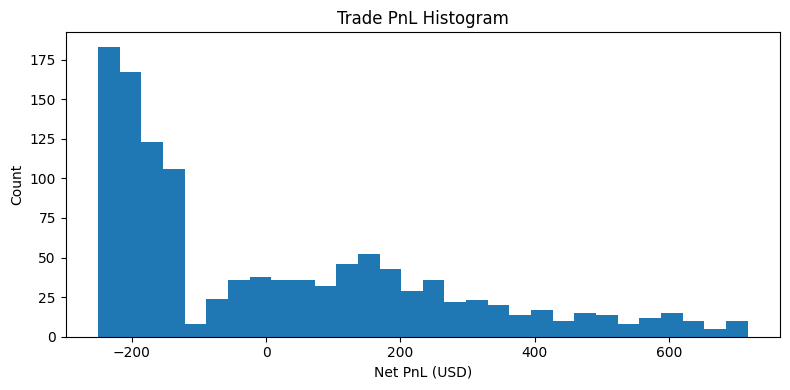

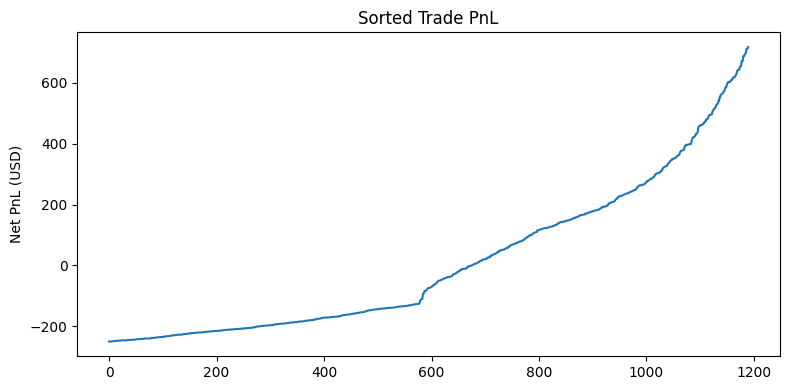

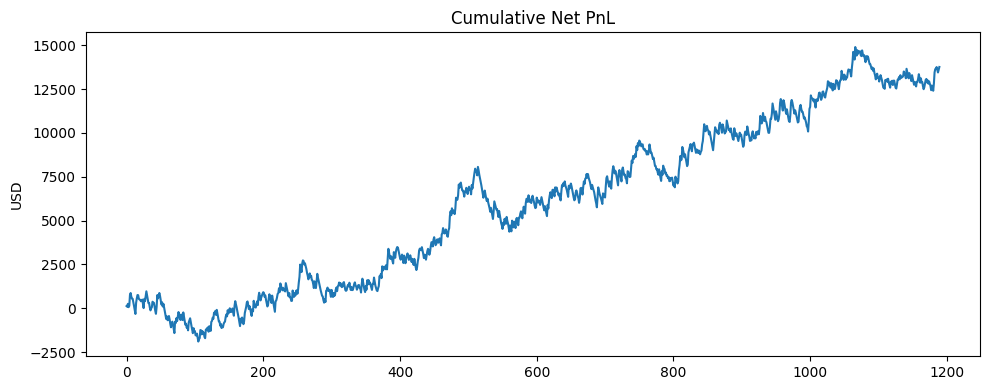

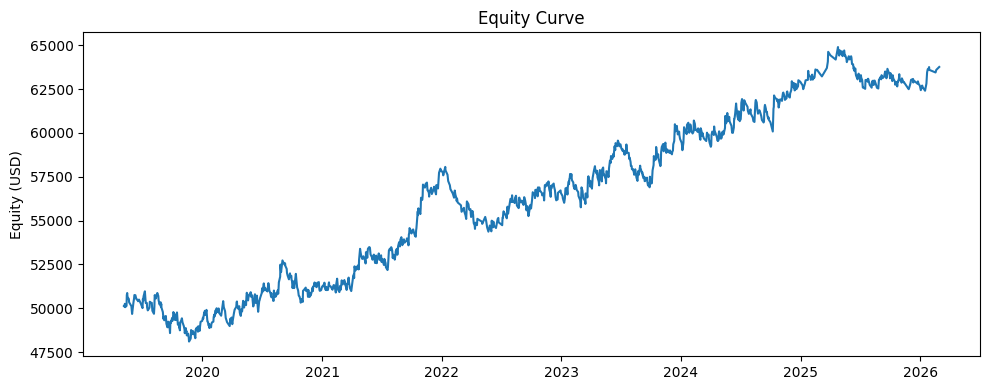

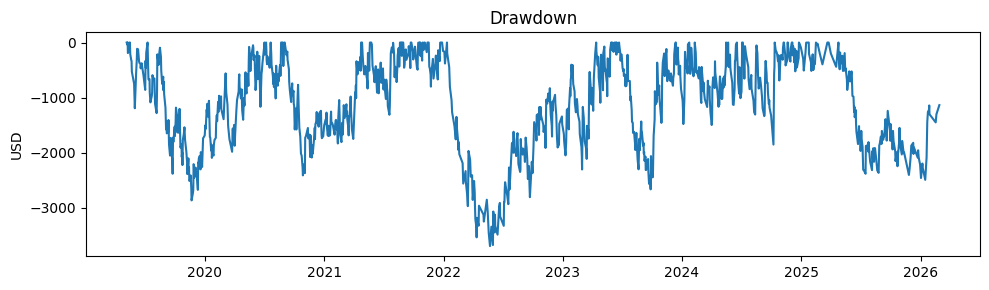

In [214]:
if not trades.empty:
    plot_trade_histogram(trades)
    plot_pnl_distribution(trades)
    plot_cumulative_pnl(trades)
    plot_equity_curve(equity)
    plot_drawdown_curve(equity)
    plt.show()

## 11) Tracer une journée spécifique pour confirmation visuelle

In [ ]:
# Tracé rapide de bougies pour une date donnée
plot_date = "2026-03-02"      # format YYYY-MM-DD
display_tz = "America/New_York"
session_only = True
session_start = "09:30"
session_end = "16:00"
start_time = None             # ex: "10:00" pour démarrer plus tard
n_bars = None                   # None pour afficher toute la session

source_df = df.copy() if "df" in globals() else df_raw.copy()

ts = pd.to_datetime(source_df["timestamp"])
if ts.dt.tz is None:
    ts_local = ts.dt.tz_localize(display_tz)
else:
    ts_local = ts.dt.tz_convert(display_tz)

plot_df = source_df.assign(timestamp_local=ts_local)
target_date = pd.Timestamp(plot_date).date()
plot_df = plot_df.loc[plot_df["timestamp_local"].dt.date == target_date].copy()

if session_only:
    hhmm = plot_df["timestamp_local"].dt.strftime("%H:%M")
    plot_df = plot_df.loc[(hhmm >= session_start) & (hhmm <= session_end)].copy()

if start_time:
    start_dt = pd.Timestamp(f"{plot_date} {start_time}").tz_localize(display_tz)
    plot_df = plot_df.loc[plot_df["timestamp_local"] >= start_dt].copy()

if n_bars is not None:
    plot_df = plot_df.head(n_bars).copy()

if plot_df.empty:
    raise ValueError(f"Aucune bougie trouvée pour {plot_date} avec les filtres actuels.")

colors = ["#16a34a" if close_ >= open_ else "#dc2626" for open_, close_ in zip(plot_df["open"], plot_df["close"])]
body = plot_df["close"] - plot_df["open"]
price_range = float(plot_df["high"].max() - plot_df["low"].min())
min_body = max(price_range * 0.001, 0.01)
body = body.mask(body.eq(0), min_body)

symbol = plot_df["symbol"].dropna().iloc[0] if "symbol" in plot_df.columns else "Instrument"

fig, ax = plt.subplots(figsize=(max(12, len(plot_df) * 0.18), 15))
x = list(range(len(plot_df)))

ax.vlines(x, plot_df["low"], plot_df["high"], color=colors, linewidth=1.0, alpha=0.9)
ax.bar(x, body, bottom=plot_df["open"], color=colors, width=0.7, align="center")

labels = plot_df["timestamp_local"].dt.strftime("%H:%M")
tick_step = max(1, len(plot_df) // 12)
ax.set_xticks(x[::tick_step])
ax.set_xticklabels(labels.iloc[::tick_step], rotation=45, ha="right")
ax.set_title(f"{symbol} | {plot_date} | {display_tz}")
ax.set_ylabel("Prix")
ax.grid(axis="y", linestyle=":", alpha=0.35)

plt.tight_layout()
plt.show()

plot_df[["timestamp_local", "open", "high", "low", "close", "volume"]].head(10)
